In [1]:
!gcloud auth application-default login

Your browser has been opened to visit:

    https://accounts.google.com/o/oauth2/auth?response_type=code&client_id=764086051850-6qr4p6gpi6hn506pt8ejuq83di341hur.apps.googleusercontent.com&redirect_uri=http%3A%2F%2Flocalhost%3A8085%2F&scope=openid+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fuserinfo.email+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fcloud-platform+https%3A%2F%2Fwww.googleapis.com%2Fauth%2Fsqlservice.login&state=pLPWiGHNBGR8BAKVhvxIQGd2n29IOZ&access_type=offline&code_challenge=3TG467PLSKFbIHm0YH8n4dp4ljML5sFEPHJABjBA2pU&code_challenge_method=S256


Credentials saved to file: [/Users/yt4/.config/gcloud/application_default_credentials.json]

These credentials will be used by any library that requests Application Default Credentials (ADC).

Quota project "open-targets-genetics-dev" was added to ADC which can be used by Google client libraries for billing and quota. Note that some services may still bill the project owning the resource.


In [2]:
import os

import hail as hl
import numpy as np
import pyspark.sql.functions as f
from pyspark.sql import DataFrame

from gentropy.common.session import Session
from gentropy.dataset.study_index import StudyIndex
from gentropy.dataset.summary_statistics import SummaryStatistics
from gentropy.dataset.study_locus import StudyLocus
from gentropy.susie_finemapper import SusieFineMapperStep
from gentropy.method.drug_enrichment_from_evid import chemblDrugEnrichment

"""Common utilities for the project."""

import os
from pathlib import Path
from gentropy.common.session import Session
import logging


def get_gcs_credentials() -> str:
    """Get the credentials for google cloud storage."""
    app_default_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/application_default_credentials.json"
    )

    service_account_credentials = os.path.join(
        os.getenv("HOME", "."), ".config/gcloud/service_account_credentials.json"
    )

    if Path(app_default_credentials).exists():
        return app_default_credentials
    else:
        raise FileNotFoundError("No GCS credentials found.")


def get_gcs_hadoop_connector_jar() -> str:
    """Get the google cloud storage hadoop connector for spark.

    This function will return the url to download the hadoop jar.
    """

    return (
        "https://storage.googleapis.com/hadoop-lib/gcs/gcs-connector-hadoop3-latest.jar"
    )


def gcs_conf(
    credentials_path=None, project="open-targets-genetics-dev"
) -> dict[str, str]:
    """Get the spark configuration with hadoop connector for google cloud storage."""
    credentials_path = credentials_path or get_gcs_credentials()
    return {
        "spark.driver.memory": "12g",
        "spark.kryoserializer.buffer.max": "500m",
        "spark.driver.maxResultSize": "2g",
        "spark.hadoop.fs.gs.impl": "com.google.cloud.hadoop.fs.gcs.GoogleHadoopFileSystem",
        "spark.jars": get_gcs_hadoop_connector_jar(),
        "spark.hadoop.google.cloud.auth.service.account.enable": "true",
        "spark.hadoop.fs.gs.project.id": project,
        "spark.hadoop.google.cloud.auth.service.account.json.keyfile": credentials_path,
        "spark.hadoop.fs.gs.requester.pays.mode": "AUTO",
    }


class GentropySession(Session):
    def __init__(self, *args, **kwargs):
        if "extended_spark_conf" in kwargs:
            kwargs["extended_spark_conf"].update(gcs_conf())
        else:
            kwargs["extended_spark_conf"] = gcs_conf()
        super().__init__(*args, **kwargs)

    @property
    def conf(self):
        logging.warning(
            "To change the config restart the session and use the `extended_spark_conf` parameter."
        )
        return self.spark.sparkContext.getConf().getAll()


session = GentropySession()


Loading BokehJS ...

/Users/yt4/Projects/gentropy/.venv/lib/python3.11/site-packages/pyspark/sql/pandas/functions.py:407: UserWarning:

In Python 3.6+ and Spark 3.0+, it is preferred to specify type hints for pandas UDF instead of specifying pandas UDF type which will be deprecated in the future releases. See SPARK-28264 for more details.

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
25/11/20 13:35:33 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


In [3]:
path_to_release_folder = "gs://open-targets-data-releases/25.06/"


si = StudyIndex.from_parquet(session, path_to_release_folder + "output/study/")
sl = StudyLocus.from_parquet(session, path_to_release_folder + "output/credible_set/")

sl_eff = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/ss60/gentropy-manuscript/chapters/variant-effect-prediction/25.07/lead_variant_effect"
)

l2g_full = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/list_of_prioritised_genes_per_CS.parquet"
)

# Load data


In [4]:
disease_index_path = path_to_release_folder + "output/disease/disease.parquet"
disease_index_orig = session.spark.read.parquet(disease_index_path)

platform_chembl_evidence_path = (
    path_to_release_folder + "output/evidence/sourceId=chembl"
)
chembl_evidence = session.spark.read.parquet(platform_chembl_evidence_path)

In [5]:
efo_to_remove = chemblDrugEnrichment.selecting_all_decendands_based_on_efo_list(
    disease_index_orig=disease_index_orig,
    efo_ids="MONDO_0045024",
)

In [6]:
chembl_evidence.show(1)

25/11/20 13:36:21 WARN SparkStringUtils: Truncated the string representation of a plan since it was too large. This behavior can be adjusted by setting 'spark.sql.debug.maxToStringFields'.


+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

In [7]:
l2g_full = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/yt4/20250403_for_gentropy_paper/l2g_full_for_enrichment"
)
l2g_full.count()

70400

In [8]:
l2g_full.show(1)

+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

# Run


In [11]:
import pandas as pd

all_enrich = []

for year in range(2006, 2007):
    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=l2g_full.filter(f.col("year") <= year).drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = str(year)
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

In [12]:
all_enrich

[  clinicalPhase  odds_ratio  p_value  ci_low  ci_high  Relative success  \
 0            2+           1      1.0     1.0      1.0                 1   
 1            3+           1      1.0     1.0      1.0                 1   
 2            4+           1      1.0     1.0      1.0                 1   
 
    ci_rs_low  ci_rs_high  rs_p_value  no_evid-low_clinphase  \
 0        1.0         1.0           1                   6163   
 1        1.0         1.0           1                  20573   
 2        1.0         1.0           1                  32813   
 
    no_evid-high_clinphase  yes_evid-low_clinphase  yes_evid-high_clinphase  \
 0                   31214                       0                        0   
 1                   16804                       0                        0   
 2                    4564                       0                        0   
 
    total_indirect_assoc datasource   drugsource  
 0                     7       2006  full_chembl  
 1              

In [ ]:
import pandas as pd

all_enrich = []

for year in range(2008, 2026):
    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=l2g_full.filter(f.col("year") <= year).drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )
    enrich["datasource"] = str(year)
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

In [17]:
year

2024

In [ ]:
year = 2025

evidence = chemblDrugEnrichment.to_disease_target_evidence(
    table_with_score=l2g_full.filter(f.col("year") <= year).drop("diseaseIds"),
    score_column="score",
    datasource_id="l2g",
    study_locus=sl,
    study_index=si,
    min_score=0.1,
)

enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=evidence,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich["datasource"] = str(year)
enrich["drugsource"] = "full_chembl"

all_enrich.append(enrich)

In [20]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)

In [ ]:
combined_enrich.iloc[0, :]

clinicalPhase                       2+
odds_ratio                    1.974747
p_value                            1.0
ci_low                        0.252737
ci_high                       15.42959
no_evid-low_clinphase             6162
no_evid-high_clinphase           31204
yes_evid-low_clinphase               1
yes_evid-high_clinphase             10
total_indirect_assoc               897
datasource                        2008
drugsource                 full_chembl
Name: 0, dtype: object

In [26]:
combined_enrich.to_csv("./data/temporal_drug_enrichment_full_chembl.csv", index=False)

# Load the data


In [ ]:
combined_enrich = pd.read_csv("./data/temporal_drug_enrichment_full_chembl.csv")

In [28]:
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]

In [29]:
combined_enrich_3 = combined_enrich[combined_enrich["clinicalPhase"] == "3+"]

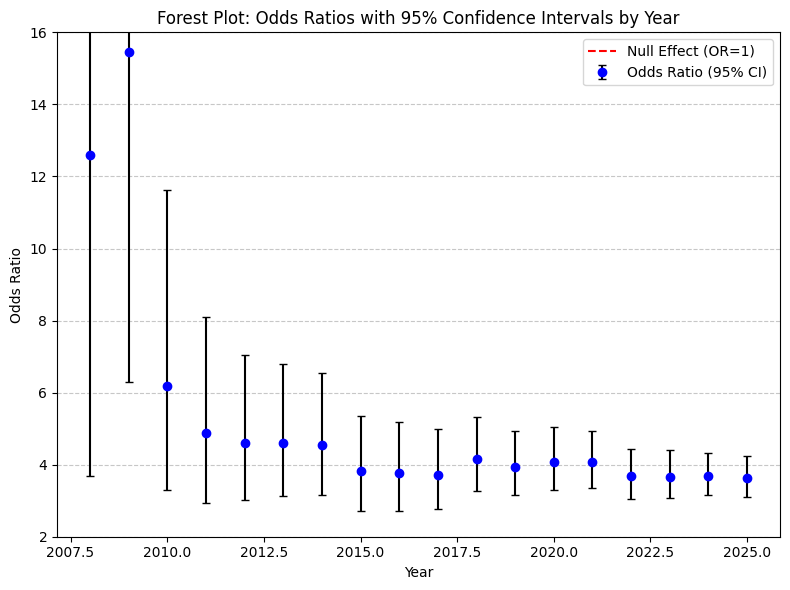

In [ ]:
import matplotlib.pyplot as plt

years = combined_enrich_4["datasource"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Create the horizontal forest plot
plt.figure(figsize=(8, 6))
plt.errorbar(
    years,
    odds_ratios,
    yerr=[odds_ratios - ci_low, ci_high - odds_ratios],
    fmt="o",
    color="blue",
    ecolor="black",
    capsize=3,
    label="Odds Ratio (95% CI)",
)

# Add labels and title
plt.axhline(y=1, color="red", linestyle="--", label="Null Effect (OR=1)")
plt.xlabel("Year")
plt.ylabel("Odds Ratio")
plt.title("Forest Plot: Odds Ratios with 95% Confidence Intervals by Year")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(2, 16)
# Show the plot
plt.tight_layout()
plt.show()

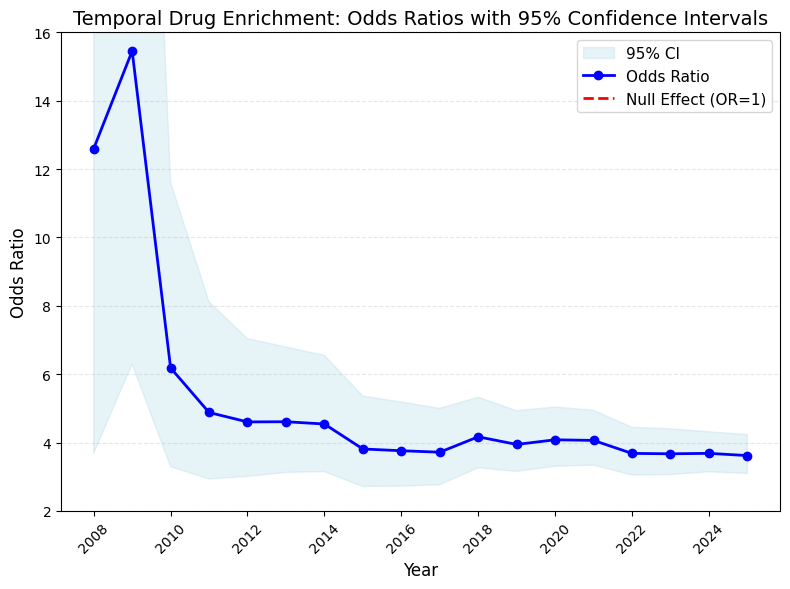

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

years = combined_enrich_4["datasource"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]

# Convert years to numeric for proper ordering
years_numeric = pd.to_numeric(years)
sorted_indices = np.argsort(years_numeric)

# Use .iloc[] for positional indexing instead of direct indexing
years_sorted = years_numeric.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]

# Create the continuous forest plot
plt.figure(figsize=(8, 6))

# Fill confidence interval area
plt.fill_between(
    years_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)

# Plot the line connecting means
plt.plot(
    years_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)

# Add reference line
plt.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize the plot
plt.xlabel("Year", fontsize=12)
plt.ylabel("Odds Ratio", fontsize=12)
plt.title(
    "Temporal Drug Enrichment: Odds Ratios with 95% Confidence Intervals", fontsize=14
)
plt.legend(fontsize=11)
plt.grid(axis="y", linestyle="--", alpha=0.3)
plt.ylim(2, 16)

# Improve x-axis
plt.xticks(years_sorted[::2], rotation=45)  # Show every other year to avoid crowding

# Show the plot
plt.tight_layout()
plt.show()

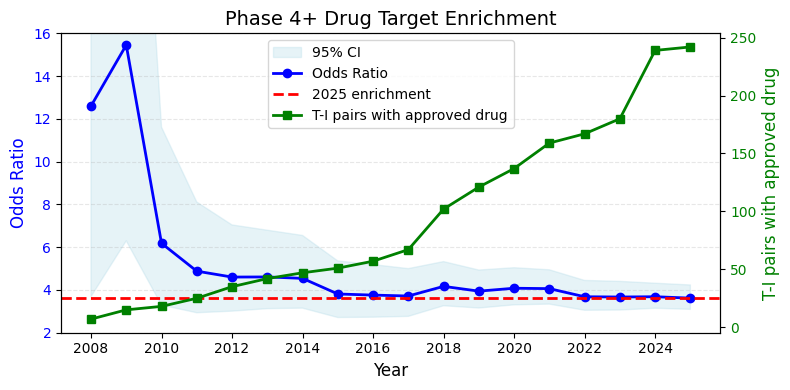

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

years = combined_enrich_4["datasource"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Convert years to numeric for proper ordering
years_numeric = pd.to_numeric(years)
sorted_indices = np.argsort(years_numeric)

# Use .iloc[] for positional indexing instead of direct indexing
years_sorted = years_numeric.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the continuous forest plot
fig, ax1 = plt.subplots(figsize=(8, 4))

# Plot odds ratios on left y-axis
ax1.fill_between(
    years_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    years_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=3.619, color="red", linestyle="--", linewidth=2, label="2025 enrichment")

# Customize left y-axis
ax1.set_xlabel("Year", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.set_ylim(2, 16)
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Create second y-axis for yes_evid-high_clinphase
ax2 = ax1.twinx()
ax2.plot(
    years_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

# Add title and legends
plt.title("Phase 4+ Drug Target Enrichment", fontsize=14)

# Combine legends from both axes
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper center", fontsize=10)

# Improve x-axis
plt.xticks(years_sorted[::2], rotation=45)

# Show the plot
plt.tight_layout()
plt.show()

In [35]:
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,drugsource
2,4+,12.599462,8.482566e-05,3.686835,43.057648,32809,4557,4,7,897,2008,full_chembl
5,4+,15.453632,1.433140e-09,6.297435,37.922542,32806,4549,7,15,1921,2009,full_chembl
8,4+,6.182892,1.701029e-07,3.291866,11.612913,32792,4546,21,18,3226,2010,full_chembl
11,4+,4.879036,2.102321e-08,2.934577,8.111899,32776,4539,37,25,5153,2011,full_chembl
14,4+,4.602782,1.124850e-10,3.009345,7.039939,32758,4529,55,35,7505,2012,full_chembl
17,4+,4.608359,1.613344e-12,3.125983,6.793695,32747,4522,66,42,9878,2013,full_chembl
20,4+,4.541911,1.181608e-13,3.149960,6.548958,32738,4517,75,47,11148,2014,full_chembl
23,4+,3.811477,1.746971e-12,2.711707,5.357273,32716,4513,97,51,14458,2015,full_chembl
26,4+,3.759951,1.415303e-13,2.726499,5.185123,32703,4507,110,57,16553,2016,full_chembl
29,4+,3.716972,1.757384e-15,2.764551,4.997512,32682,4497,131,67,20232,2017,full_chembl


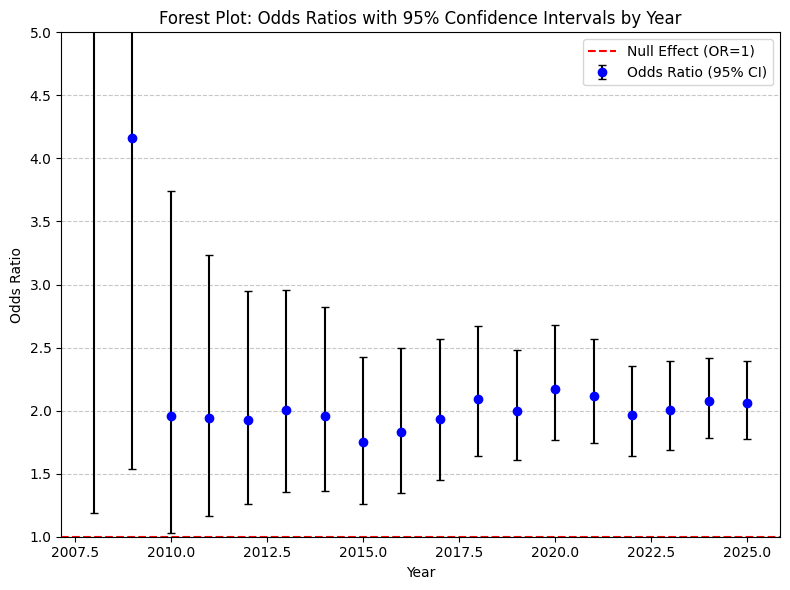

In [ ]:
import matplotlib.pyplot as plt

years = combined_enrich_3["datasource"]
odds_ratios = combined_enrich_3["odds_ratio"]
ci_low = combined_enrich_3["ci_low"]
ci_high = combined_enrich_3["ci_high"]

# Create the horizontal forest plot
plt.figure(figsize=(8, 6))
plt.errorbar(
    years,
    odds_ratios,
    yerr=[odds_ratios - ci_low, ci_high - odds_ratios],
    fmt="o",
    color="blue",
    ecolor="black",
    capsize=3,
    label="Odds Ratio (95% CI)",
)

# Add labels and title
plt.axhline(y=1, color="red", linestyle="--", label="Null Effect (OR=1)")
plt.xlabel("Year")
plt.ylabel("Odds Ratio")
plt.title("Forest Plot: Odds Ratios with 95% Confidence Intervals by Year")
plt.legend()
plt.grid(axis="y", linestyle="--", alpha=0.7)
plt.ylim(1, 5)

# Show the plot
plt.tight_layout()
plt.show()

# Enrichment based on pleiotropy score at different bins


In [9]:
l2g_full.show(1)

+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|        studyLocusId|             studyId|         geneId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|
+--------------------+--------------------+---------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+
|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|ENSG00000152954|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|
+--------------------+--------------------+---------------+-----------------+---

In [10]:
l2g_full.count()

70400

In [ ]:
g_p_s = session.spark.read.parquet(
    "gs://genetics-portal-dev-analysis/dc16/output/gentropy_paper/genes_therapeutic_areas"
)

In [12]:
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [ ]:
l2g_full = l2g_full.join(
    g_p_s.select("geneId", "uniqueDiseases"), on="geneId", how="inner"
).cache()
l2g_full.count()

70400

In [14]:
l2g_full.show(1)

+---------------+--------------------+--------------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+--------------+
|         geneId|        studyLocusId|             studyId|            score|eQTL_coloc|pQTL_coloc|VEP|distanceTSS|                 maf|     variantId|year|is_nfe|     diseaseIds|nfe_common|non_nfe_common|rare|           absBeta|uniqueDiseases|
+---------------+--------------------+--------------------+-----------------+----------+----------+---+-----------+--------------------+--------------+----+------+---------------+----------+--------------+----+------------------+--------------+
|ENSG00000152954|cd9dd38e1f85a069d...|FINNGEN_R12_H7_IR...|0.344258189201355|         0|         0|  0|          1|0.029878971255673223|6_23867964_T_C|2024|     0|[MONDO_0004773]|         0|             1|   0|0.4207366138701276|            10|
+---------------+---

In [18]:
import pandas as pd
import numpy as np

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
unique_diseases_stats = l2g_full.select("uniqueDiseases").toPandas()["uniqueDiseases"]
quantiles = np.quantile(unique_diseases_stats, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1.   4.   8.  14.  26. 148.]


In [ ]:
# Create 5 bins based on uniqueDiseases quantiles
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i+1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: uniqueDiseases >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper)
        )
    else:
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper)
        )

    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=filtered_data.drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_1.0_4.0: uniqueDiseases >= 1.0 and < 4.0


Processing bin_2_4.0_8.0: uniqueDiseases >= 4.0 and < 8.0


Processing bin_3_8.0_14.0: uniqueDiseases >= 8.0 and < 14.0


Processing bin_4_14.0_26.0: uniqueDiseases >= 14.0 and < 26.0


Processing bin_5_26.0_148.0: uniqueDiseases >= 26.0 and < 148.0


In [23]:
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
0,2+,1.201586,0.661149,0.652131,2.213984,6151,31141,12,73,14655,bin_5_26.0_148.0,26.0,148.0,5,full_chembl
1,3+,0.899264,0.663487,0.584553,1.383408,20524,16768,49,36,14655,bin_5_26.0_148.0,26.0,148.0,5,full_chembl
2,4+,1.669484,0.067943,0.968292,2.878446,32744,4548,69,16,14655,bin_5_26.0_148.0,26.0,148.0,5,full_chembl


In [24]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)

In [25]:
combined_enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
0,2+,1.608251,8.374517e-02,0.940043,2.751437,6148,31092,15,122,48683,bin_1_1.0_4.0,1.0,4.0,1,full_chembl
1,3+,2.136150,1.418126e-05,1.507681,3.026594,20523,16717,50,87,48683,bin_1_1.0_4.0,1.0,4.0,1,full_chembl
2,4+,4.035853,9.675662e-13,2.841896,5.731422,32725,4515,88,49,48683,bin_1_1.0_4.0,1.0,4.0,1,full_chembl
3,2+,1.792515,2.239930e-02,1.085404,2.960292,6146,31060,17,154,38020,bin_2_4.0_8.0,4.0,8.0,2,full_chembl
4,3+,2.737986,3.291229e-10,1.978783,3.788474,20520,16686,53,118,38020,bin_2_4.0_8.0,4.0,8.0,2,full_chembl
5,4+,5.044878,2.320673e-21,3.713453,6.853674,32712,4494,101,70,38020,bin_2_4.0_8.0,4.0,8.0,2,full_chembl
6,2+,1.810457,4.471633e-02,1.020606,3.211576,6150,31095,13,119,27288,bin_3_8.0_14.0,8.0,14.0,3,full_chembl
7,3+,2.012781,9.968924e-05,1.415159,2.862777,20523,16722,50,82,27288,bin_3_8.0_14.0,8.0,14.0,3,full_chembl
8,4+,2.709557,2.848719e-06,1.844994,3.979254,32717,4528,96,36,27288,bin_3_8.0_14.0,8.0,14.0,3,full_chembl
9,2+,2.064320,1.258259e-03,1.288232,3.307957,6144,31016,19,198,23058,bin_4_14.0_26.0,14.0,26.0,4,full_chembl


In [26]:
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]

In [27]:
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
2,4+,4.035853,9.675662e-13,2.841896,5.731422,32725,4515,88,49,48683,bin_1_1.0_4.0,1.0,4.0,1,full_chembl
5,4+,5.044878,2.320673e-21,3.713453,6.853674,32712,4494,101,70,38020,bin_2_4.0_8.0,4.0,8.0,2,full_chembl
8,4+,2.709557,2.848719e-06,1.844994,3.979254,32717,4528,96,36,27288,bin_3_8.0_14.0,8.0,14.0,3,full_chembl
11,4+,3.535724,1.880478e-15,2.658136,4.703048,32667,4493,146,71,23058,bin_4_14.0_26.0,14.0,26.0,4,full_chembl
14,4+,1.669484,6.794305e-02,0.968292,2.878446,32744,4548,69,16,14655,bin_5_26.0_148.0,26.0,148.0,5,full_chembl


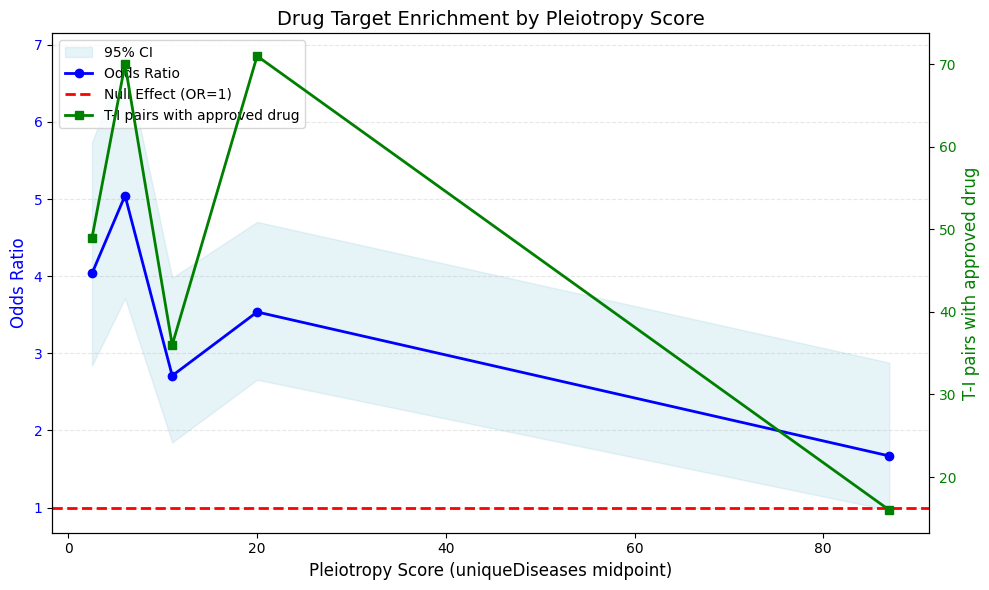

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_midpoints.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(
    bin_midpoints_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

In [30]:
import pandas as pd
import numpy as np

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
unique_diseases_stats = l2g_full.select("uniqueDiseases").toPandas()["uniqueDiseases"]
quantiles = np.quantile(unique_diseases_stats, [0, 0.25, 0.5, 0.75, 1.0])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1.   5.  11.  22. 148.]


In [ ]:
# Create 4 bins based on uniqueDiseases quantiles
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i+1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: uniqueDiseases >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper)
        )
    else:
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper)
        )

    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=filtered_data.drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_1.0_5.0: uniqueDiseases >= 1.0 and < 5.0


Processing bin_2_5.0_11.0: uniqueDiseases >= 5.0 and < 11.0


Processing bin_3_11.0_22.0: uniqueDiseases >= 11.0 and < 22.0


Processing bin_4_22.0_148.0: uniqueDiseases >= 22.0 and < 148.0


In [34]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
2,4+,4.745946,4.283454e-21,3.528298,6.383816,32701,4491,112,73,60634,bin_1_1.0_5.0,1.0,5.0,1,full_chembl
5,4+,3.713128,6.652945e-17,2.801428,4.921533,32668,4490,145,74,42325,bin_2_5.0_11.0,5.0,11.0,2,full_chembl
8,4+,3.075569,1.288967e-10,2.246487,4.210630,32681,4508,132,56,29336,bin_3_11.0_22.0,11.0,22.0,3,full_chembl
11,4+,2.539203,3.843679e-06,1.760651,3.662027,32702,4525,111,39,19409,bin_4_22.0_148.0,22.0,148.0,4,full_chembl


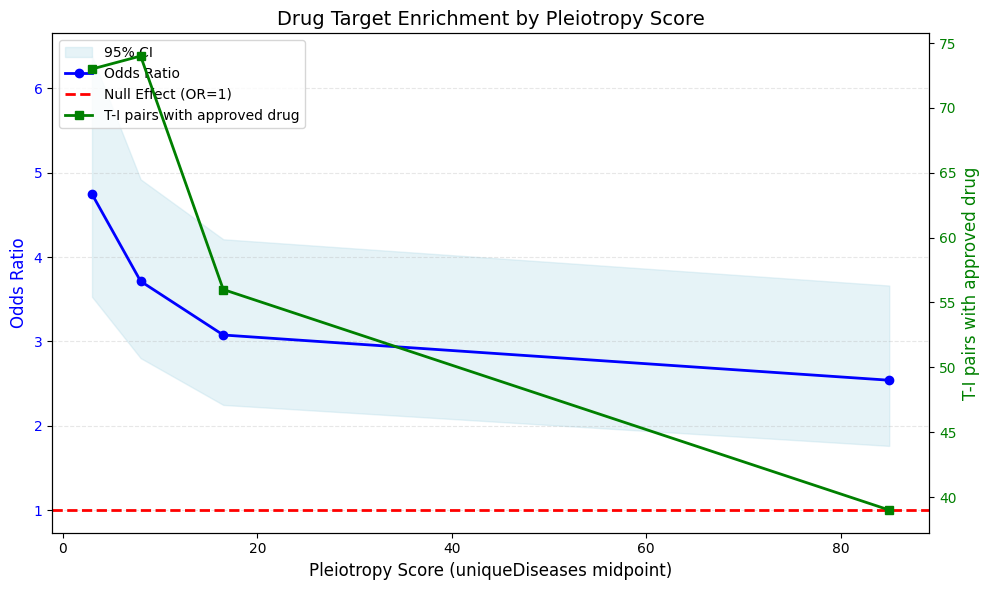

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_midpoints.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(
    bin_midpoints_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

In [44]:
import pandas as pd
import numpy as np

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
unique_diseases_stats = l2g_full.select("uniqueDiseases").toPandas()["uniqueDiseases"]
quantiles = np.quantile(unique_diseases_stats, [0, 0.1, 0.48, 0.71, 1.0])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1.   2.  10.  20. 148.]


In [ ]:
# Create 4 bins based on uniqueDiseases quantiles
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i+1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: uniqueDiseases >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper)
        )
    else:
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper)
        )

    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=filtered_data.drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_1.0_2.0: uniqueDiseases >= 1.0 and < 2.0


Processing bin_2_2.0_10.0: uniqueDiseases >= 2.0 and < 10.0


Processing bin_3_10.0_20.0: uniqueDiseases >= 10.0 and < 20.0


Processing bin_4_20.0_148.0: uniqueDiseases >= 20.0 and < 148.0


In [46]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
2,4+,4.326837,6.698908e-06,2.410068,7.768045,32783,4546,30,18,19044,bin_1_1.0_2.0,1.0,2.0,1,full_chembl
5,4+,4.232803,4.185286e-30,3.373686,5.310697,32605,4444,208,120,79525,bin_2_2.0_10.0,2.0,10.0,2,full_chembl
8,4+,2.745034,4.271769e-07,1.913459,3.938003,32705,4523,108,41,31069,bin_3_10.0_20.0,10.0,20.0,3,full_chembl
11,4+,2.968340,4.088765e-11,2.210513,3.985973,32659,4501,154,63,22066,bin_4_20.0_148.0,20.0,148.0,4,full_chembl


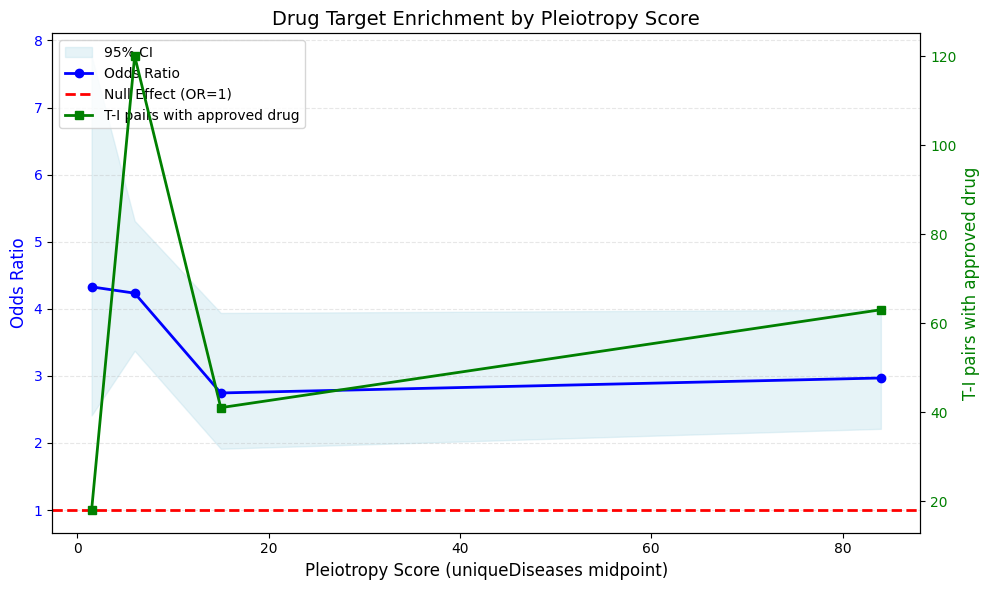

25/09/26 03:12:02 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 272087 ms exceeds timeout 120000 ms
25/09/26 03:12:02 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/26 03:12:02 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_midpoints.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(
    bin_midpoints_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import numpy as np

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
unique_diseases_stats = l2g_full.select("uniqueDiseases").toPandas()["uniqueDiseases"]
quantiles = np.quantile(unique_diseases_stats, [0, 0.1, 0.25, 0.48, 0.71, 1.0])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1.   2.   5.  10.  20. 148.]


In [ ]:
# Create 4 bins based on uniqueDiseases quantiles
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i+1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: uniqueDiseases >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper)
        )
    else:
        filtered_data = l2g_full.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper)
        )

    evidence = chemblDrugEnrichment.to_disease_target_evidence(
        table_with_score=filtered_data.drop("diseaseIds"),
        score_column="score",
        datasource_id="l2g",
        study_locus=sl,
        study_index=si,
        min_score=0.1,
    )

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=evidence,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_1.0_2.0: uniqueDiseases >= 1.0 and < 2.0


Processing bin_2_2.0_5.0: uniqueDiseases >= 2.0 and < 5.0


Processing bin_3_5.0_10.0: uniqueDiseases >= 5.0 and < 10.0


Processing bin_4_10.0_20.0: uniqueDiseases >= 10.0 and < 20.0


Processing bin_5_20.0_148.0: uniqueDiseases >= 20.0 and < 148.0


In [22]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
2,4+,4.326837,6.698908e-06,2.410068,7.768045,32783,4546,30,18,19044,bin_1_1.0_2.0,1.0,2.0,1,full_chembl
5,4+,4.868867,1.180048e-16,3.455051,6.861219,32731,4509,82,55,41590,bin_2_2.0_5.0,2.0,5.0,2,full_chembl
8,4+,3.748020,3.360308e-15,2.774007,5.064030,32687,4499,126,65,37935,bin_3_5.0_10.0,5.0,10.0,3,full_chembl
11,4+,2.745034,4.271769e-07,1.913459,3.938003,32705,4523,108,41,31069,bin_4_10.0_20.0,10.0,20.0,4,full_chembl
14,4+,2.968340,4.088765e-11,2.210513,3.985973,32659,4501,154,63,22066,bin_5_20.0_148.0,20.0,148.0,5,full_chembl


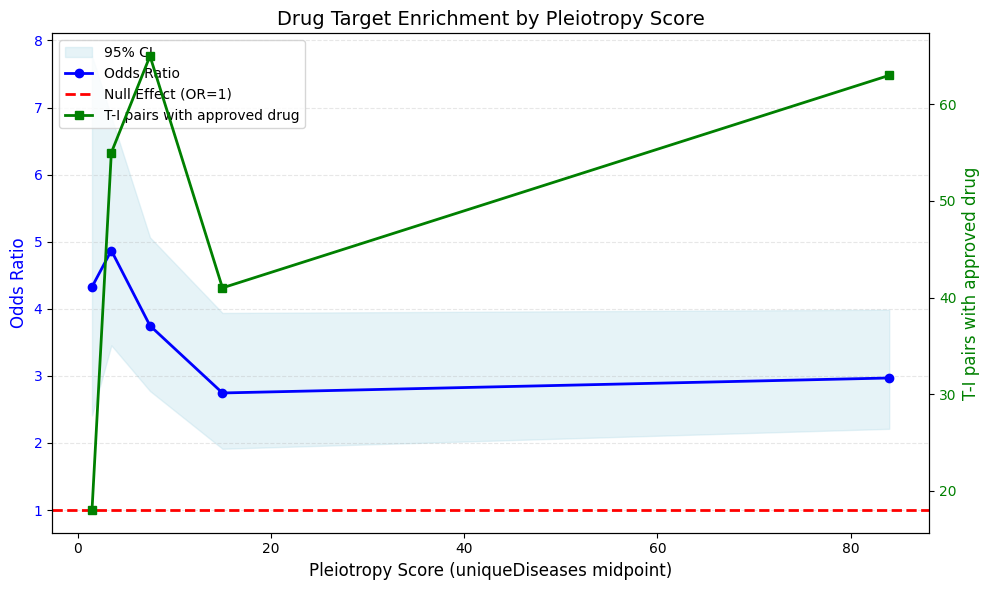

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_midpoints.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(
    bin_midpoints_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

In [26]:
evidence.show(1)

+----------+------------+---------------+-------------+------------------+--------------------+
|datatypeId|datasourceId|       targetId|    diseaseId|     resourceScore|        studyLocusId|
+----------+------------+---------------+-------------+------------------+--------------------+
|      GWAS|         l2g|ENSG00000275410|MONDO_0005148|0.4956789016723633|b3bdd85050c56b13f...|
+----------+------------+---------------+-------------+------------------+--------------------+
only showing top 1 row



In [24]:
chembl_evidence.show(1)

+------------+---------------+-------------+-------------------+--------+----------+----+---------------------------+---------------------------+---------------------------------+--------------------------------+-----------------+-------------+----------+--------------------+--------+-------------+---------------------+--------------+-----------------+--------+----------------+---------------+----------+--------+-------------------+----------+----------------+--------------------+-------------------+-------------------------+-------------------------------------+-------------------------------------+--------------+----------+------------+-----------------+----------+----------------------------+-------------------+--------------+---------+--------------------------------+--------------------------------+--------------+--------------+--------+---------+----------+------------+-----------+--------------+-------------+----+------------------------+-----------------+-----------------------

In [ ]:
chembl = chemblDrugEnrichment.process_chembl_evidence(chembl_evidence, efo_to_remove)
chembl.count()

37377

In [ ]:
chembl.show(1)

+---------------+-------------+----------------+
|       targetId|    diseaseId|maxClinicalPhase|
+---------------+-------------+----------------+
|ENSG00000004779|MONDO_0020121|             3.0|
+---------------+-------------+----------------+
only showing top 1 row



25/09/26 18:18:15 WARN HeartbeatReceiver: Removing executor driver with no recent heartbeats: 261257 ms exceeds timeout 120000 ms
25/09/26 18:18:15 WARN SparkContext: Killing executors is not supported by current scheduler.
25/09/26 18:18:21 WARN Executor: Issue communicating with driver in heartbeater
org.apache.spark.SparkException: Exception thrown in awaitResult: 
	at org.apache.spark.util.SparkThreadUtils$.awaitResult(SparkThreadUtils.scala:56)
	at org.apache.spark.util.ThreadUtils$.awaitResult(ThreadUtils.scala:310)
	at org.apache.spark.rpc.RpcTimeout.awaitResult(RpcTimeout.scala:75)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:101)
	at org.apache.spark.rpc.RpcEndpointRef.askSync(RpcEndpointRef.scala:85)
	at org.apache.spark.storage.BlockManagerMaster.registerBlockManager(BlockManagerMaster.scala:80)
	at org.apache.spark.storage.BlockManager.reregister(BlockManager.scala:642)
	at org.apache.spark.executor.Executor.reportHeartBeat(Executor.scala:1223)
	at o

In [ ]:
chembl = chembl.drop("maxClinicalPhase").withColumn("resourceScore", f.lit(1)).cache()
chembl.show(1)

+---------------+-----------+-------------+
|       targetId|  diseaseId|resourceScore|
+---------------+-----------+-------------+
|ENSG00000007314|EFO_0000555|            1|
+---------------+-----------+-------------+
only showing top 1 row



In [ ]:
genes_to_remove = (
    l2g_full.select("geneId").distinct().withColumnRenamed("geneId", "targetId").cache()
)
genes_to_remove.count()

8285

In [35]:
chembl.count()

37377

In [ ]:
chembl = chembl.join(genes_to_remove, on="targetId", how="left_anti").cache()
chembl.count()

18897

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=chembl,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)

In [38]:
enrich

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,0.993707,8.235175e-01,0.940863,1.049520,3039,15441,3124,15773,63002
1,3+,0.965682,9.410039e-02,0.927109,1.005859,10091,8389,10482,8415,63002
2,4+,0.740715,3.091163e-21,0.695957,0.788352,15924,2556,16889,2008,63002


In [39]:
enrich["datasource"] = "0"
enrich["bin_lower"] = 0
enrich["bin_upper"] = 1
enrich["bin_number"] = 0
enrich["drugsource"] = "full_chembl"

all_enrich.append(enrich)

In [40]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,drugsource
2,4+,4.326837,6.698908e-06,2.410068,7.768045,32783,4546,30,18,19044,bin_1_1.0_2.0,1.0,2.0,1,full_chembl
5,4+,4.868867,1.180048e-16,3.455051,6.861219,32731,4509,82,55,41590,bin_2_2.0_5.0,2.0,5.0,2,full_chembl
8,4+,3.748020,3.360308e-15,2.774007,5.064030,32687,4499,126,65,37935,bin_3_5.0_10.0,5.0,10.0,3,full_chembl
11,4+,2.745034,4.271769e-07,1.913459,3.938003,32705,4523,108,41,31069,bin_4_10.0_20.0,10.0,20.0,4,full_chembl
14,4+,2.968340,4.088765e-11,2.210513,3.985973,32659,4501,154,63,22066,bin_5_20.0_148.0,20.0,148.0,5,full_chembl
17,4+,0.740715,3.091163e-21,0.695957,0.788352,15924,2556,16889,2008,63002,0,0.0,1.0,0,full_chembl


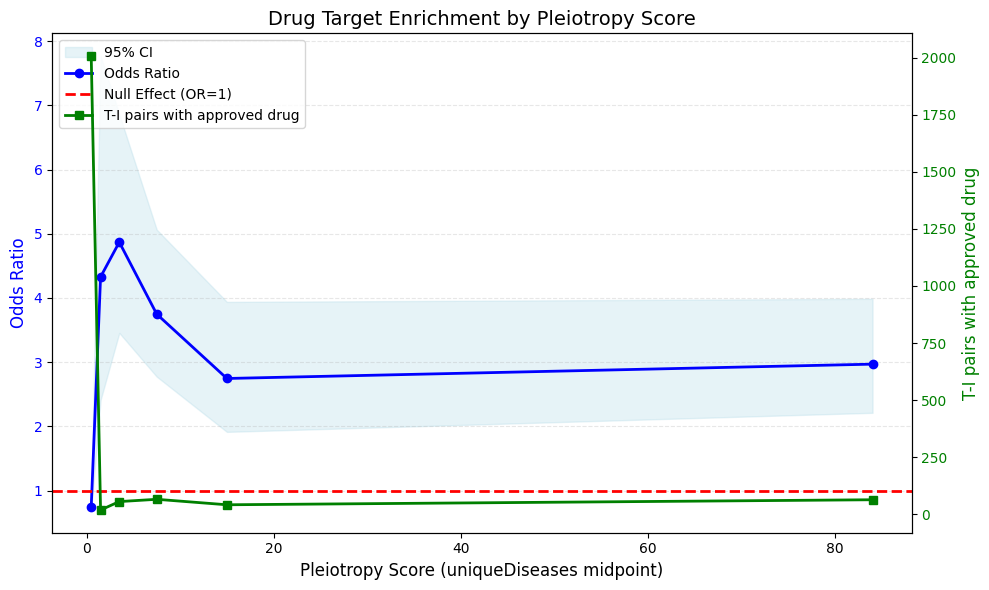

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_midpoints.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Second y-axis
ax2 = ax1.twinx()
ax2.plot(
    bin_midpoints_sorted,
    yes_evid_high_sorted,
    "s-",
    color="green",
    linewidth=2,
    markersize=6,
    label="T-I pairs with approved drug",
)
ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color="green")
ax2.tick_params(axis="y", labelcolor="green")

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Combine legends
lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

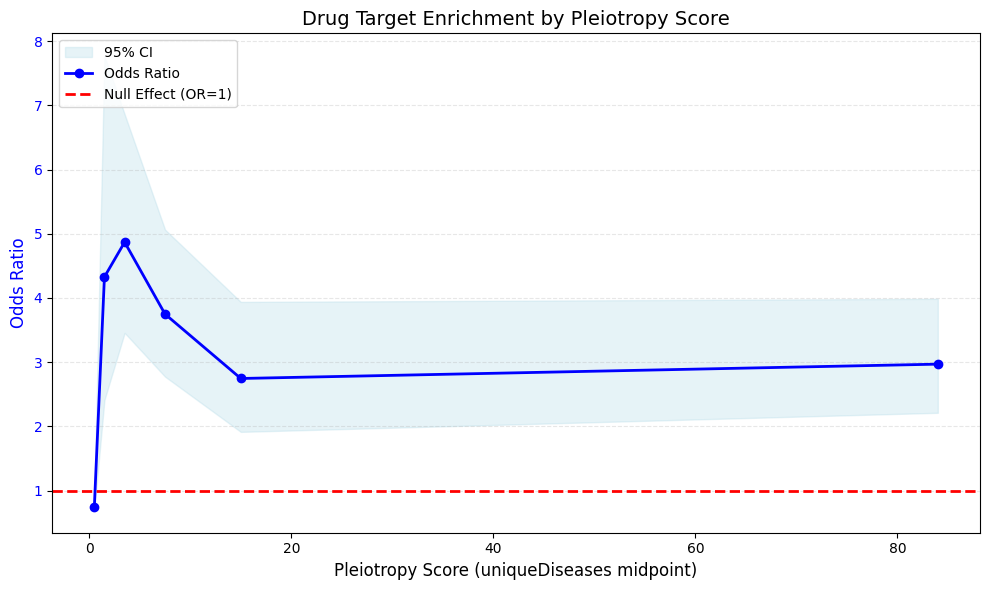

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_midpoints.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(10, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

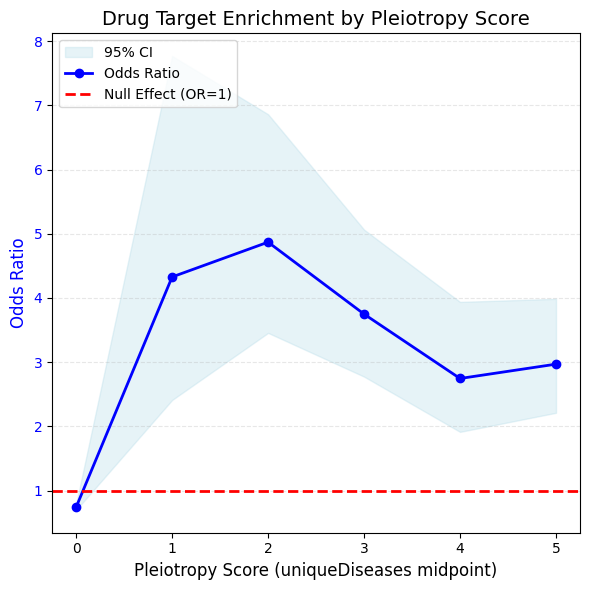

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_number.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

# Gene separation (no trait)


In [ ]:
import pandas as pd
import numpy as np

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
quantiles = np.array([1, 2, 5, 10, 148])

print(f"Bin boundaries (uniqueDiseases): {quantiles}")

Bin boundaries (uniqueDiseases): [  1   2   5  10 148]


In [ ]:
genes_to_remove = (
    l2g_full.select("geneId").distinct().withColumnRenamed("geneId", "targetId").cache()
)
genes_to_remove.count()


25/09/26 12:24:40 WARN CacheManager: Asked to cache already cached data.


8285

In [ ]:
chembl = chemblDrugEnrichment.process_chembl_evidence(chembl_evidence, efo_to_remove)
chembl_for_analysis = (
    chembl.drop("maxClinicalPhase").withColumn("resourceScore", f.lit(1)).cache()
)
chembl_for_analysis.count()

25/09/26 12:24:43 WARN CacheManager: Asked to cache already cached data.


37377

In [ ]:
chembl_bin = chembl_for_analysis.join(
    genes_to_remove, on="targetId", how="left_anti"
).cache()
chembl_bin.count()

25/09/26 12:24:44 WARN CacheManager: Asked to cache already cached data.


18897

In [ ]:
enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
    evid=chembl_bin,
    disease_index_orig=disease_index_orig,
    chembl_orig=chembl_evidence,
    indirect_assoc_score_thr=0.1,
    efo_ancestors_to_remove=["MONDO_0045024"],
)
enrich

25/09/26 12:24:50 WARN CacheManager: Asked to cache already cached data.        
25/09/26 12:24:51 WARN CacheManager: Asked to cache already cached data.


,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc
0,2+,0.993707,8.235175e-01,0.940863,1.049520,3039,15441,3124,15773,63002
1,3+,0.965682,9.410039e-02,0.927109,1.005859,10091,8389,10482,8415,63002
2,4+,0.740715,3.091163e-21,0.695957,0.788352,15924,2556,16889,2008,63002


In [ ]:
enrich["datasource"] = "0"
enrich["bin_lower"] = 0
enrich["bin_upper"] = 1
enrich["bin_number"] = 0
enrich["n_genes_in_chembl"] = chembl_bin.select("targetId").distinct().count()
enrich["drugsource"] = "full_chembl"

all_enrich.append(enrich)

In [59]:
g_p_s.show(1)

+---------------+--------------+----------------------+------------+------------+------+--------------+----------------------+----------------------+-----------------------+-------------------+-----------------+---------------------------+----------------------+---------------------+---------------+-----------------------+---------------------------------+--------------------------+----------------------+----------------------------+--------------------+----------------------------------------+-------------+-------------------+------------------+--------------------+-------------------+-----------------------------+----------------------------------+----------------------------------+-------------+-----+------------+--------------+-------------+-------------+-------------+------------+-----------------+------------------+
|         geneId|uniqueDiseases|uniqueTherapeuticAreas|maxEQTLColoc|maxPQTLColoc|maxVEP|maxDistanceTSS|minEffectiveSampleSize|maxEffectiveSampleSize|earliestPublicati

In [ ]:
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i+1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: uniqueDiseases >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = g_p_s.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") <= upper)
        )
    else:
        filtered_data = g_p_s.filter(
            (f.col("uniqueDiseases") >= lower) & (f.col("uniqueDiseases") < upper)
        )

    genes_to_include = (
        filtered_data.select("geneId")
        .distinct()
        .withColumnRenamed("geneId", "targetId")
    )
    chembl_bin = chembl_for_analysis.join(
        genes_to_include, on="targetId", how="inner"
    ).cache()

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=chembl_bin,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["n_genes_in_chembl"] = chembl_bin.select("targetId").distinct().count()
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_1.0_2.0: uniqueDiseases >= 1 and < 2


25/09/26 12:25:06 WARN CacheManager: Asked to cache already cached data.
25/09/26 12:25:12 WARN CacheManager: Asked to cache already cached data.        
25/09/26 12:25:13 WARN CacheManager: Asked to cache already cached data.
25/09/26 12:25:30 WARN CacheManager: Asked to cache already cached data.        


Processing bin_2_2.0_5.0: uniqueDiseases >= 2 and < 5


25/09/26 12:25:36 WARN CacheManager: Asked to cache already cached data.        
25/09/26 12:25:37 WARN CacheManager: Asked to cache already cached data.
25/09/26 12:25:54 WARN CacheManager: Asked to cache already cached data.        


Processing bin_3_5.0_10.0: uniqueDiseases >= 5 and < 10


25/09/26 12:26:01 WARN CacheManager: Asked to cache already cached data.        
25/09/26 12:26:02 WARN CacheManager: Asked to cache already cached data.


Processing bin_4_10.0_148.0: uniqueDiseases >= 10 and < 148


In [63]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,bin_lower,bin_upper,bin_number,n_genes_in_chembl,drugsource
2,4+,0.740715,3.091163e-21,0.695957,0.788352,15924,2556,16889,2008,63002,0,0,1,0,580,full_chembl
5,4+,1.151604,9.975172e-04,1.059906,1.251235,27864,3789,4949,775,19317,bin_1_1.0_2.0,1,2,1,198,full_chembl
8,4+,1.300263,4.064631e-10,1.199608,1.409363,27920,3717,4893,847,20072,bin_2_2.0_5.0,2,5,2,230,full_chembl
11,4+,1.177394,1.300784e-03,1.067809,1.298225,29538,4037,3275,527,12948,bin_3_5.0_10.0,5,10,3,133,full_chembl
14,4+,1.046598,4.138522e-01,0.938609,1.167012,30006,4157,2807,407,11450,bin_4_10.0_148.0,10,148,4,132,full_chembl


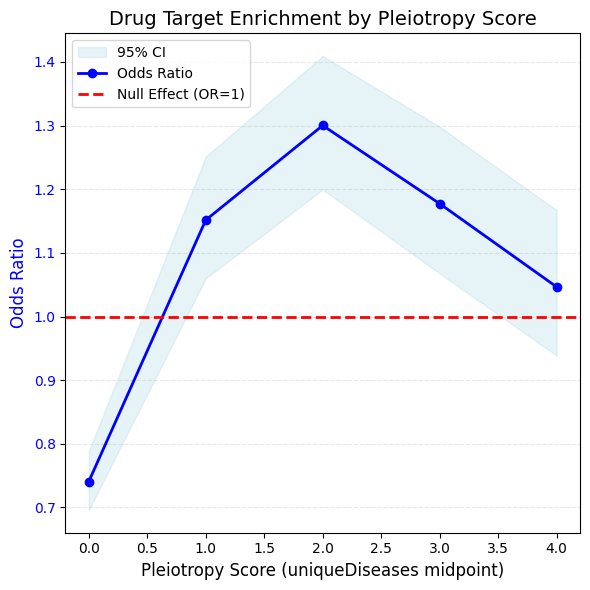

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_number.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

# Gene separation (no trait) by constraint


In [ ]:
target = session.spark.read.csv(
    "./data/target_with_constraints_2509.csv", header=True, inferSchema=True
)
target.count()

20083

In [66]:
target = target.filter(f.col("lof_constr").isNotNull())
target.count()

18097

In [70]:
target.show(1)

+---------------+--------------+----------+----------+----------+
|       targetId|       biotype|syn_constr|mis_constr|lof_constr|
+---------------+--------------+----------+----------+----------+
|ENSG00000001084|protein_coding|  -0.18886|    2.1807|    -0.404|
+---------------+--------------+----------+----------+----------+
only showing top 1 row



In [ ]:
import pandas as pd
import numpy as np

all_enrich = []

# Calculate quantiles for uniqueDiseases to create 5 bins
lof_constr = target.select("lof_constr").toPandas()["lof_constr"]
quantiles = np.quantile(lof_constr, [0, 0.2, 0.4, 0.6, 0.8, 1.0])

print(f"Bin boundaries (lof_constr): {quantiles}")

Bin boundaries (lof_constr): [-1.998 -1.394 -1.079 -0.852 -0.576 -0.04 ]


In [77]:
lof_constr

0       -0.404
1       -0.371
2       -0.685
3       -0.590
4       -1.244
         ...  
18092   -1.904
18093   -0.439
18094   -0.971
18095   -0.936
18096   -1.841
Name: lof_constr, Length: 18097, dtype: float64

In [ ]:
for i, (lower, upper) in enumerate(zip(quantiles[:-1], quantiles[1:])):
    bin_name = f"bin_{i+1}_{lower:.1f}_{upper:.1f}"
    print(f"Processing {bin_name}: lof_constr >= {lower} and < {upper}")

    # Filter data based on uniqueDiseases bin
    if i == len(quantiles) - 2:  # Last bin includes upper boundary
        filtered_data = target.filter(
            (f.col("lof_constr") >= lower) & (f.col("lof_constr") <= upper)
        )
    else:
        filtered_data = target.filter(
            (f.col("lof_constr") >= lower) & (f.col("lof_constr") < upper)
        )

    genes_to_include = filtered_data.select("targetId").distinct()
    chembl_bin = chembl_for_analysis.join(
        genes_to_include, on="targetId", how="inner"
    ).cache()

    enrich = chemblDrugEnrichment.drug_enrichemnt_from_evidence(
        evid=chembl_bin,
        disease_index_orig=disease_index_orig,
        chembl_orig=chembl_evidence,
        indirect_assoc_score_thr=0.1,
        efo_ancestors_to_remove=["MONDO_0045024"],
    )

    enrich["datasource"] = bin_name
    enrich["n_genes_in_chembl"] = chembl_bin.select("targetId").distinct().count()
    enrich["bin_lower"] = lower
    enrich["bin_upper"] = upper
    enrich["bin_number"] = i + 1
    enrich["drugsource"] = "full_chembl"

    all_enrich.append(enrich)

Processing bin_1_-2.0_-1.4: lof_constr >= -1.998 and < -1.394


Processing bin_2_-1.4_-1.1: lof_constr >= -1.394 and < -1.079


Processing bin_3_-1.1_-0.9: lof_constr >= -1.079 and < -0.852


Processing bin_4_-0.9_-0.6: lof_constr >= -0.852 and < -0.576


Processing bin_5_-0.6_-0.0: lof_constr >= -0.576 and < -0.04


In [80]:
combined_enrich = pd.concat(all_enrich, ignore_index=True)
combined_enrich_4 = combined_enrich[combined_enrich["clinicalPhase"] == "4+"]
combined_enrich_4

,clinicalPhase,odds_ratio,p_value,ci_low,ci_high,no_evid-low_clinphase,no_evid-high_clinphase,yes_evid-low_clinphase,yes_evid-high_clinphase,total_indirect_assoc,datasource,n_genes_in_chembl,bin_lower,bin_upper,bin_number,drugsource
2,4+,0.885758,1.146654e-02,0.806212,0.973152,28362,4007,4451,557,17066,bin_1_-2.0_-1.4,153,-1.998,-1.394,1,full_chembl
5,4+,0.912017,4.860236e-02,0.832567,0.999049,28127,3962,4686,602,17387,bin_2_-1.4_-1.1,158,-1.394,-1.079,2,full_chembl
8,4+,1.332203,1.717072e-10,1.222564,1.451675,28739,3839,4074,725,17379,bin_3_-1.1_-0.9,216,-1.079,-0.852,3,full_chembl
11,4+,0.893352,3.868187e-03,0.827240,0.964747,25583,3644,7230,920,28148,bin_4_-0.9_-0.6,283,-0.852,-0.576,4,full_chembl
14,4+,1.152495,2.589416e-05,1.079134,1.230843,22805,3031,10008,1533,38145,bin_5_-0.6_-0.0,392,-0.576,-0.040,5,full_chembl


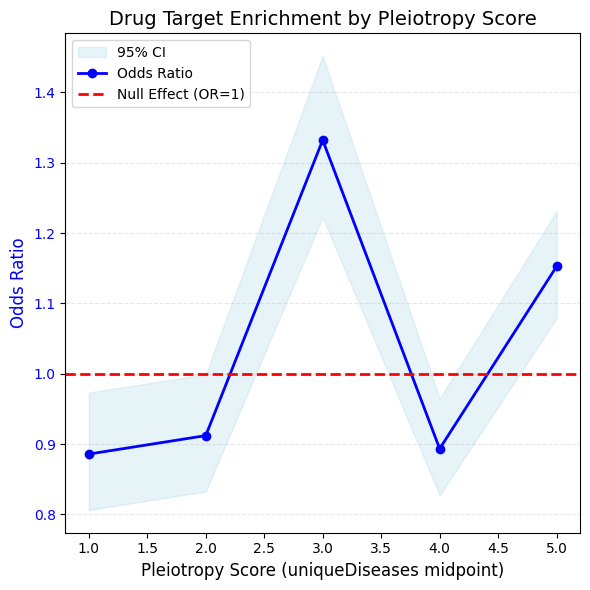

In [ ]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

bin_lower = combined_enrich_4["bin_lower"]
bin_upper = combined_enrich_4["bin_upper"]
bin_number = combined_enrich_4["bin_number"]
odds_ratios = combined_enrich_4["odds_ratio"]
ci_low = combined_enrich_4["ci_low"]
ci_high = combined_enrich_4["ci_high"]
yes_evid_high = combined_enrich_4["yes_evid-high_clinphase"]

# Calculate bin midpoints for x-axis
bin_midpoints = (bin_lower + bin_upper) / 2

# Sort by bin_number for proper ordering
sorted_indices = np.argsort(bin_number)

# Sort all variables
bin_midpoints_sorted = bin_number.iloc[sorted_indices]
odds_ratios_sorted = odds_ratios.iloc[sorted_indices]
ci_low_sorted = ci_low.iloc[sorted_indices]
ci_high_sorted = ci_high.iloc[sorted_indices]
yes_evid_high_sorted = yes_evid_high.iloc[sorted_indices]

# Create the plot
fig, ax1 = plt.subplots(figsize=(6, 6))

# Plot odds ratios on left y-axis
ax1.fill_between(
    bin_midpoints_sorted,
    ci_low_sorted,
    ci_high_sorted,
    alpha=0.3,
    color="lightblue",
    label="95% CI",
)
ax1.plot(
    bin_midpoints_sorted,
    odds_ratios_sorted,
    "o-",
    color="blue",
    linewidth=2,
    markersize=6,
    label="Odds Ratio",
)
ax1.axhline(y=1, color="red", linestyle="--", linewidth=2, label="Null Effect (OR=1)")

# Customize axes
ax1.set_xlabel("Pleiotropy Score (uniqueDiseases midpoint)", fontsize=12)
ax1.set_ylabel("Odds Ratio", fontsize=12, color="blue")
ax1.tick_params(axis="y", labelcolor="blue")
ax1.grid(axis="y", linestyle="--", alpha=0.3)

# Remove the second y-axis section entirely:
# ax2 = ax1.twinx()
# ax2.plot(bin_midpoints_sorted, yes_evid_high_sorted, 's-', color='green',
#          linewidth=2, markersize=6, label="T-I pairs with approved drug")
# ax2.set_ylabel("T-I pairs with approved drug", fontsize=12, color='green')
# ax2.tick_params(axis='y', labelcolor='green')

plt.title("Drug Target Enrichment by Pleiotropy Score", fontsize=14)

# Use only the first legend
ax1.legend(loc="upper left", fontsize=10)

plt.tight_layout()
plt.show()

In [ ]:
  contingency_table = [
                [N_negG - X_negG, X_negG],
                [N_G - X_G, X_G],
            ]

In [1]:
  contingency_table = [
                [1, 2],
                [3, 4],
            ]

In [6]:
contingency_table[1][0]

3

In [7]:
from scipy.stats import norm

In [ ]:
norm.sf(abs(28**0.5)) * 2

1.2131545083660686e-07

In [14]:
from scipy.stats import chi2

In [15]:
chi2.sf(28, df=1)

1.2131545083660726e-07